# Introduction to Python Project : FoodHub Data Analysis
# Context
The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin on the delivery order from the restaurants.

# Objective
The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

### Data Dictionary

order_id: Unique ID of the order

customer_id: ID of the customer who ordered the food

restaurant_name: Name of the restaurant

cuisine_type: Cuisine ordered by the customer

cost_of_the_order: Cost of the order

day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

rating: Rating given by the customer out of 5

food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [156]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import numpy as np
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline



### Understanding the structure of the data

In [157]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [158]:

# setting column to the maximum column width as per the data
pd.set_option('max_colwidth', None)

In [159]:
# Write your code here to read the data
data_frame = pd.read_csv("/content/drive/MyDrive/Santhosh-Notebooks/foodhub_order.csv")

In [160]:
# Write your code here to view the first 5 rows
data_frame.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [161]:
# Write your code here
print("There are in total", data_frame.shape[0], 'rows and', data_frame.shape[1], "columns.")

There are in total 1898 rows and 9 columns.


#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [162]:
# Write your code here
print("Following are the data types of columns in the table")
data_frame.info()

Following are the data types of columns in the table
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

From the above table we can we have 9 columns , among them one is type float, four are type integer and four are of object type and there no null values in any of the column , because number of non null value is exactly matching number of rows


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [163]:
# Write your code here
missingvals=data_frame.isnull().sum()
print(missingvals)

total_missing=missingvals.sum()
print("Total number of missing values are",total_missing)

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64
Total number of missing values are 0


#### Observations:

There are no missing values in the dataset ,all the columns are populated with
values of corresponding data type


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [164]:
# Write your code here
#data["food_preparation_time"].describe()
print("Minimum time it takes for food to be prepared once an order is placed is", data_frame["food_preparation_time"].min())
print("Average time it takes for food to be prepared once an order is placed is", data_frame["food_preparation_time"].mean())
print("Maximum time it takes for food to be prepared once an order is placed is", data_frame["food_preparation_time"].max())

Minimum time it takes for food to be prepared once an order is placed is 20
Average time it takes for food to be prepared once an order is placed is 27.371970495258168
Maximum time it takes for food to be prepared once an order is placed is 35


#### Observations:

The Average time taken to prepare an order is 27.37 minutes, the minimum time taken
is 20 minutes and maximum time taken to prepare an order is 35 minutes


### **Question 5:** How many orders are not rated? [1 mark]

In [165]:
# Write the code here
#replace the Not given string with NaN and then take a total count for NaN values
data_frame["rating"]=data_frame['rating'].replace('Not given',np.nan)
print("Total number of order which are not rated are",data_frame["rating"].isna().sum())



Total number of order which are not rated are 736


#### Observations:

Out of 1898 orders , 736 orders are not rated. So approximately 39%  orders are not rated


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

# **Cusine Type**

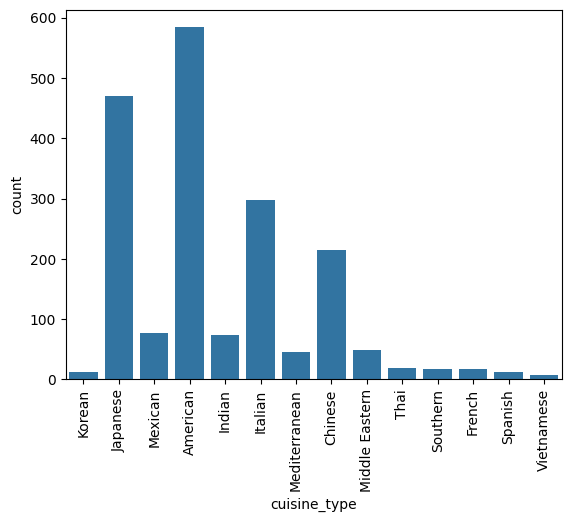

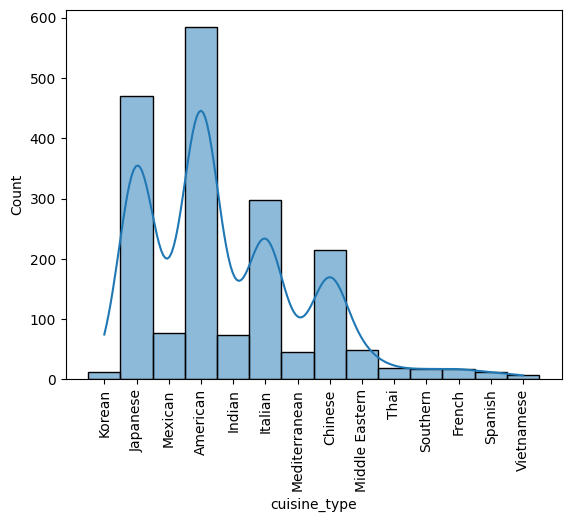

In [166]:
sns.countplot(data=data_frame,x='cuisine_type');
plt.xticks(rotation=90)
plt.show()

sns.histplot(data=data_frame,x='cuisine_type',kde=True);
plt.xticks(rotation=90)
plt.show()



1.   Most popular cuisine ordered is Americian
2.   Top 3 cusines ordered are American,Japnese and Italian
3.   Chinese cuisine is 4th most popular.
4.   Indian and Mexican are next in line in terms of popularity , recieving      moderate order volume
6. Mediterranean and Middle Eastern food have relatively lower volume.
5. Thai, French,Southern and Spanish cuisines appear at bottom of distribution.  Vietnamesse being least popular







# **Resturant Name**

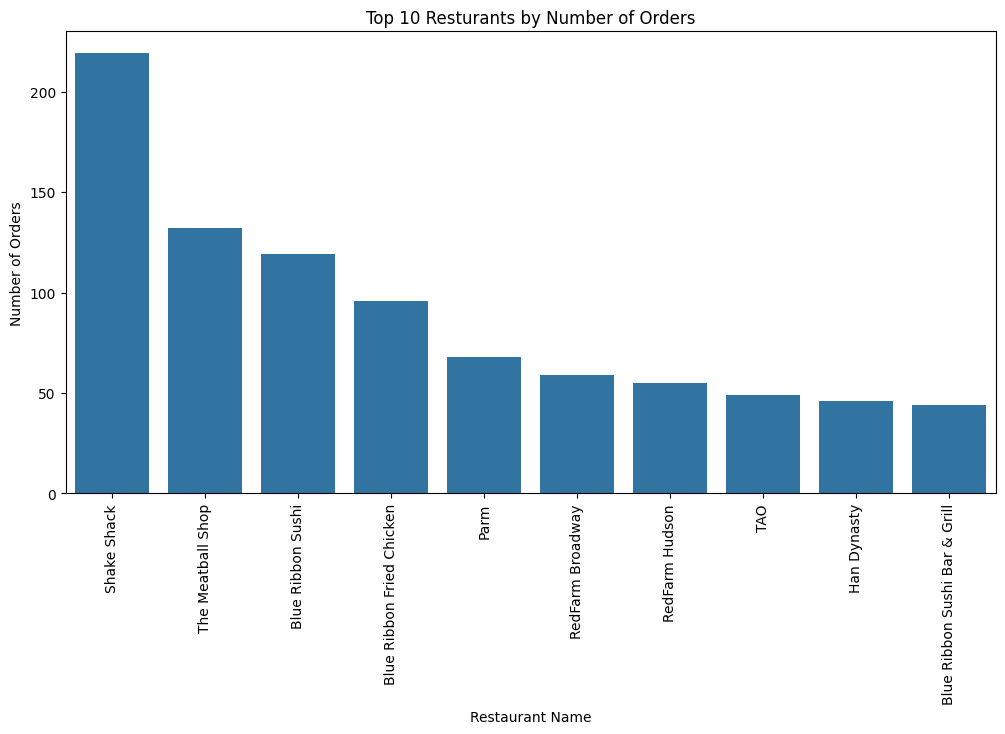

In [167]:
resturant_count=data_frame['restaurant_name'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=resturant_count.index,y=resturant_count.values)
plt.title("Top 10 Resturants by Number of Orders")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.show()


Observations: The above graph shows top 10 resturants by volume of the  order recieved.

# **COST OF THE ORDER**

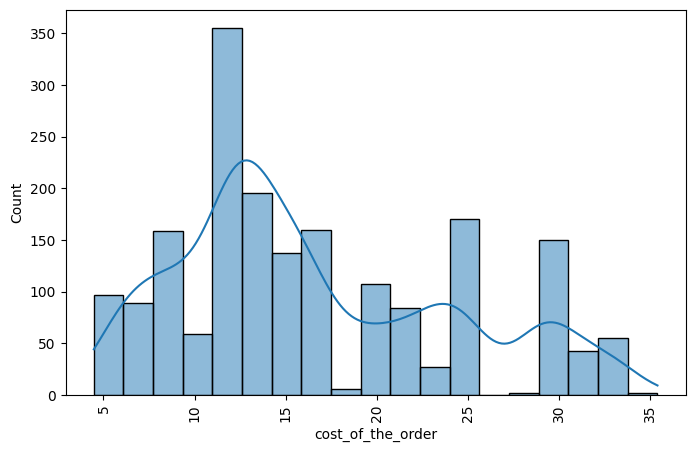

In [168]:
plt.figure(figsize=(8,5))
sns.histplot(data_frame['cost_of_the_order'],kde=True);
plt.xticks(rotation=90)
plt.show()

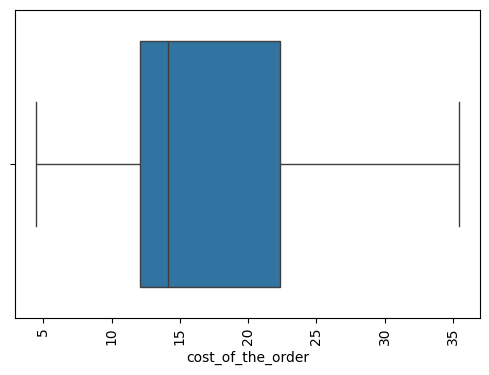

In [169]:


plt.figure(figsize=(6,4))
sns.boxplot(data=data_frame,x='cost_of_the_order');
plt.xticks(rotation=90)
plt.show()

The combined observation from historgam and boxplot are as follows

1. The minimum cost  for an order is 5 USD ,indicating platform offering low-cost items
2. 25% of the orders placed cost less than 12 USD, which implies that significant number of customers prefer lower priced items
3. The median order value is 14 USD, which is a typical customer spending
4. 75% of the order cost less than 21 USD, only small portion of the orders are expensive.
5. Maximum price of order is 35 USD.
6. There are no outliers in dataset provided for order price.
7. The distribution is slightly right skewed , indicating there are very few items pulling the tail



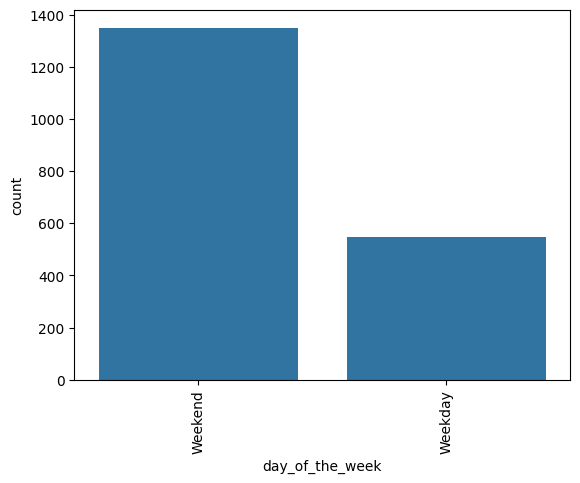

In [170]:
sns.countplot(data=data_frame,x='day_of_the_week');
plt.xticks(rotation=90)
plt.show()



1.   From the histogram it is clear that number of order in the weekend is quite high, which is reflecting the trend in most of metro cities ,newyork is no different
2.   weekend orders are 2.5 times of order palced in weekdays combined.



# **Food Preparation Time**

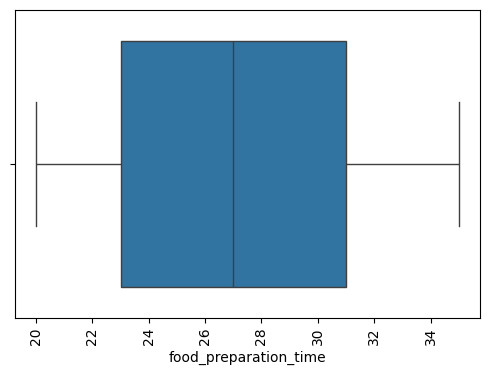

In [171]:


plt.figure(figsize=(6,4))
sns.boxplot(data=data_frame,x='food_preparation_time');
plt.xticks(rotation=90)
plt.show()

1. On an average resturants takes 27 minutes to prepare an order
2. The minimum taken to prepare an order is 20 minutes and maximum time taken is 35 minutes
3. 50% of the order takes between 23 minutes and 31 minutes suggesting food preparation time for most of the resturants falls in this range
4. There are no significants outliers for preparation time, suggesting stable and reliable prepartion time

# **Delivery Time**

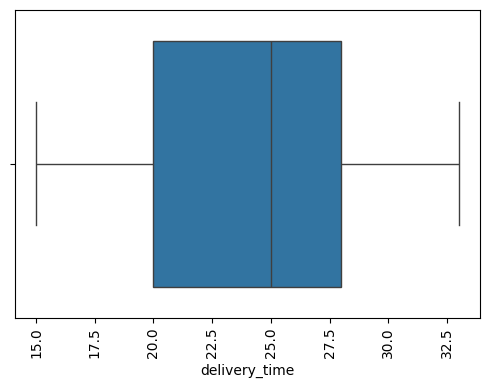

In [172]:

plt.figure(figsize=(6,4))
sns.boxplot(data=data_frame,x='delivery_time');
plt.xticks(rotation=90)
plt.show()

**Observations**

1. 50% of orders takes 25 minutes or less to get delivered.
2. 25 percentile of orders are delivered within 20 minutes.
3. 75 percentile of orderes are delivered with 28 minutes.
4. minimum delivery time is 15 minutes and maximum delivery time is 34 mins
5. Delivery performance is predictable and there are no signifiacnt outliers.

# **Rating**

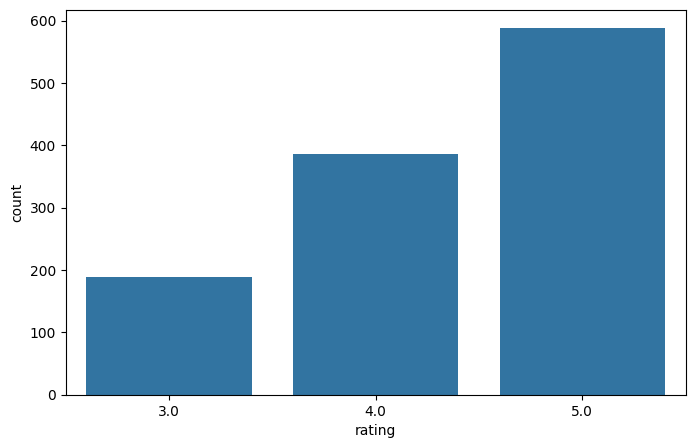

In [173]:
data_frame['rating'] = data_frame['rating'].astype(float)
plt.figure(figsize=(8,5))
sns.countplot(x=data_frame['rating']);
#plt.xticks(rotation=90)
plt.show()

we have cleaned the missing data and converted rating column of type float. From the above
graph we can observe the following

1. Close to 600 orders have recieved 5 star rating , close to 400 orders have recieved 4 start rating which implies customers are satisfied with food served via foodhub

2. Close to 200 orders have recived 3 star rating which is roughly 11 % of orders.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [174]:
# Write the code here
#we can group the orders by resturant names and get the total order for each resturant , filter out top 5 by using head after sorting in descending order


print("The top 5 restaurants in terms of the number of orders received are")
top_5_df=data_frame.groupby(['restaurant_name'])['order_id'].count().sort_values(ascending=False).head(5)
top_5_df

The top 5 restaurants in terms of the number of orders received are


,order_id
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

The top 5 resturants as per order volume are shown above.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [175]:
# Write the code here

weekend_frame=data_frame[data_frame['day_of_the_week']=='Weekend']
print("Total number of orders placed in weekend",len(weekend_frame))
popular=weekend_frame.groupby('cuisine_type')[['order_id']].count().sort_values('order_id',ascending=False).reset_index().head(1)
print("The most popular cuisine on weekends is\n",popular)




Total number of orders placed in weekend 1351
The most popular cuisine on weekends is
   cuisine_type  order_id
0     American       415


**Observations**

Most popular cuisine is American which is approximately 30% of weekend orders


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [176]:
# Write the code here
#data_frame.shape
total_orders=len(data_frame)
print("Observations:")
print("Total number of orders are",total_orders)
orders_more_than_20=len(data_frame[data_frame['cost_of_the_order']>20])
print("Total number of orders which cost more than 20 dollars are",orders_more_than_20)
percentage=(orders_more_than_20/total_orders)*100
print("Percentage of orders which cost more than 20 dollars is",percentage)


Observations:
Total number of orders are 1898
Total number of orders which cost more than 20 dollars are 555
Percentage of orders which cost more than 20 dollars is 29.24130663856691


### **Question 10**: What is the mean order delivery time? [1 mark]

In [177]:
# Write the code here
#data_frame.info()
print("Observations:")
print("The mean order delivery time is",data_frame['delivery_time'].mean())

Observations:
The mean order delivery time is 24.161749209694417


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [178]:
# Write the code here
print("The top 3 most frequent customers and number of orders placed are")
data_frame.groupby('customer_id')[['order_id']].count().sort_values('order_id',ascending=False).head(3)

The top 3 most frequent customers and number of orders placed are


,order_id
customer_id,
52832,13
47440,10
83287,9


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


# Correlation With Cuisine Type

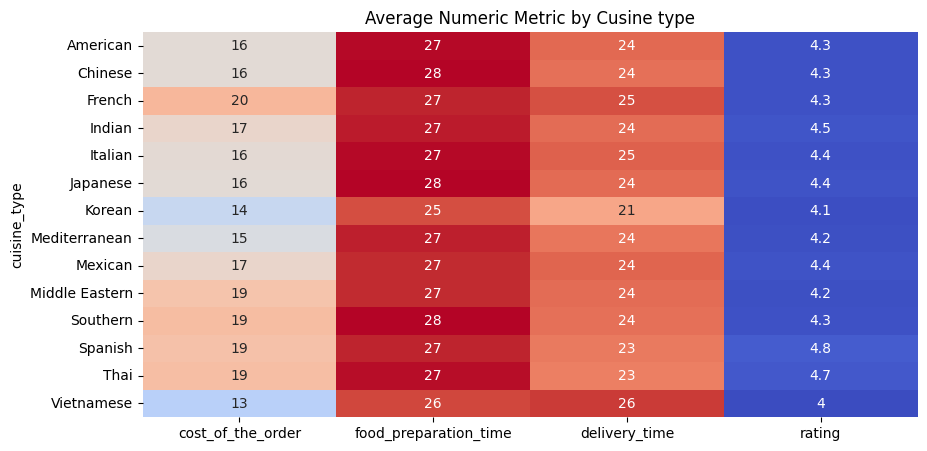

In [179]:
cols=['cost_of_the_order','food_preparation_time','delivery_time','rating']
mean_by_cusine=data_frame.groupby('cuisine_type')[cols].mean()
plt.figure(figsize=(10,5))
sns.heatmap(mean_by_cusine,annot=True,cbar=False,cmap='coolwarm')
plt.title("Average Numeric Metric by Cusine type")
plt.show()


1. Premium cuisines like French,Middle Eastern ,Sothern,Spanish and Thai Costs around 19 to 20 USD. French being the most expensive at 20 USD average price.
 Korean and Vietnamese Cuisine have the lowest average cost cost around 13 to 14 USD. American, Chinese, Indian , Italian and Mexican  costs between 16 to 17 USD

2. Food prepartion time is fairly consistent which ranges from 26-28 minutes, implying that cuisine type doesnt have significant impact on the preparation time

3. Delivery time also clustered around 21 to 26 minutes. Korean cuisine has least delivery time and Vietnamese cusine has highest delivery time. But overall cuisine type donot have much impact on the delivery time and also reflecting consistent logistic used for food delivery

5. Spanish is highly rated at 4.8, Thai is very close by at 4.7. Indian, Italian ,Japanese,Mexican are rated at 4.4. Next in line are French, Chinese,American and Souther at 4.3. The least rated cuisine are Korean and Vietnamese


# Top 10  Highly Rated Resturants

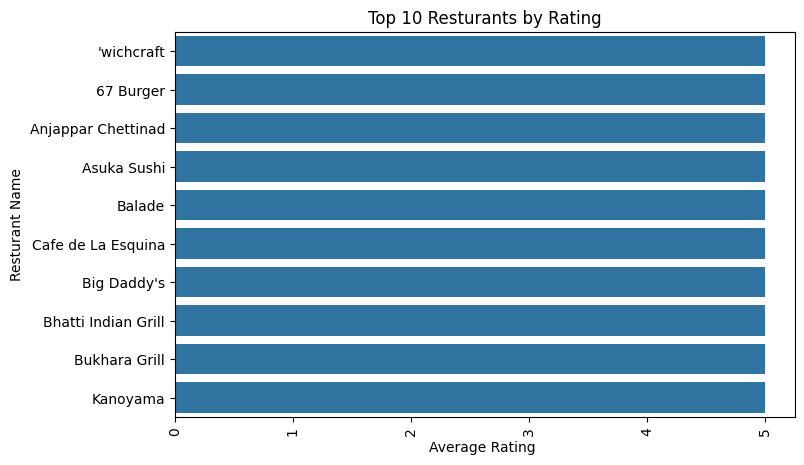

In [180]:
avg_rating=data_frame.groupby('restaurant_name')['rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=avg_rating.values,y=avg_rating.index)
plt.title("Top 10 Resturants by Rating")
plt.xlabel("Average Rating ")
plt.ylabel("Resturant Name")
plt.xticks(rotation=90)
plt.show()

**Observation:**

The above bargraph depicts top 10 resturants by average rating.But the problem with this approach is even the resturants with a single order and high rating (5 star)will be considered better than resturant with 200 orders and 4.7 Rating. In order to overcome this problem we can select resturants which has got atleast 50 orders, this will remove the noise from resturants with less orders.

Text(0, 0.5, 'Resturant Name')

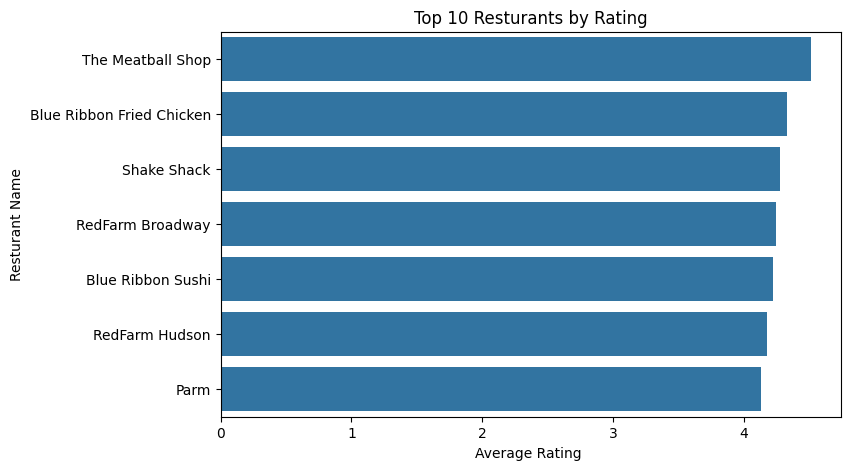

In [181]:
"""
To overcome the problem me=ntioned above we can select resturants which has got atleast 50 orders, this will remove the noise from resturants with less orders.
we will be creating two additional columns avg_rating which stores the mean rating for each resturant and order_count which stores the total number of orders for each resturant.
from the filtered data frame , we will get the top 10 resturants by average rating and plot the graph
"""


resturant_stats=data_frame.groupby('restaurant_name').agg(avg_rating=('rating','mean'),order_count=('order_id','count')).reset_index()
filtered=resturant_stats[resturant_stats['order_count']>50]
top_filtered=filtered.sort_values('avg_rating',ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_filtered['avg_rating'],y=top_filtered['restaurant_name'])
plt.title("Top 10 Resturants by Rating")
plt.xlabel("Average Rating ")
plt.ylabel("Resturant Name")



**Observation:**

The above graph shows top 10 resturants by average rating , we have considered resturants who have executed more than 50 orders. The Top 3 resturants by Average rating are The Meatball Soup, Blue Ribbon fried Chicken and Shake Shack.

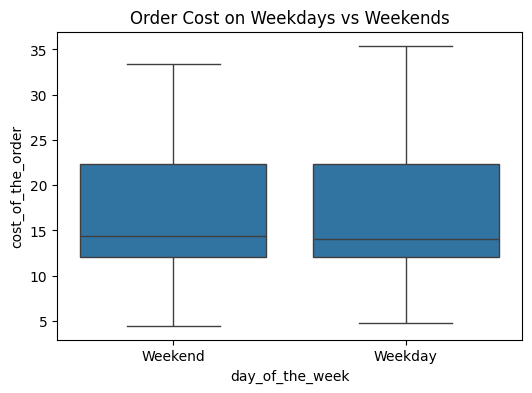

In [182]:
plt.figure(figsize=(6,4))
sns.boxplot(x='day_of_the_week', y='cost_of_the_order', data=data_frame);
plt.title("Order Cost on Weekdays vs Weekends")
plt.show()

1. Average cost for orders on weekend and weekdays are same around 12 USD
2. Weekend orders indicate lower minimum values of around 4 USD , indicating few cheaper orders are placed in weekends
3. Upper-end order value is higher during weekdays indicating higher spend or surcharges being added in weekdays due to various factors like traffic.
4. Overall there is no significant difference in spending in weekend and weekdays.


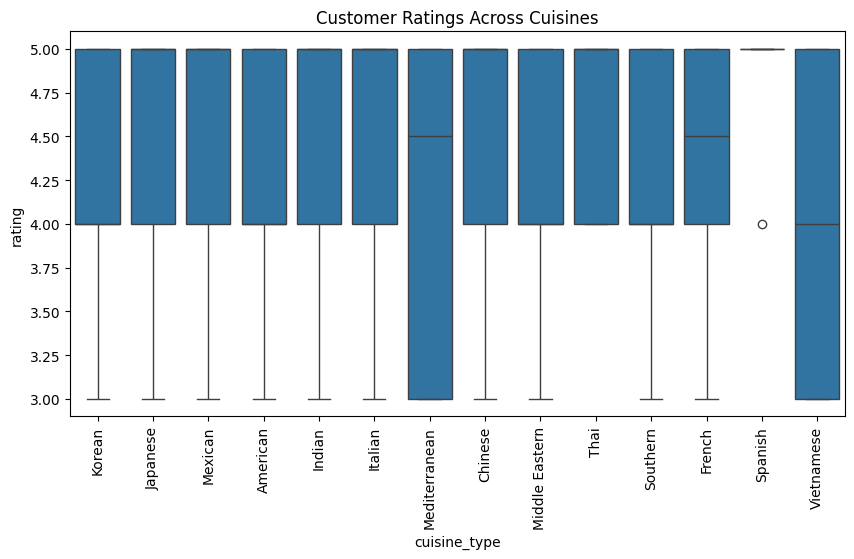

In [183]:

plt.figure(figsize=(10,5))
sns.boxplot(x='cuisine_type', y='rating', data=data_frame)
plt.xticks(rotation=90)
plt.title("Customer Ratings Across Cuisines")
plt.show()




In [184]:
print("Number of orders by cuisine type")
print(data_frame['cuisine_type'].value_counts())
print("="*300)
print("Rating details by cuisine type")
print(data_frame.groupby('cuisine_type')['rating'].describe())
print("="*300)

print("Mediterranean orders and Rating")
medi_df=data_frame[data_frame['cuisine_type']=='Mediterranean']
print(f"Total Orders{len(medi_df)}")
print(f"Resturnat Names {medi_df['restaurant_name'].unique()}")
print(f"Orders Rated (below 4) {len(medi_df[medi_df['rating'] <4])}")



print("="*300)
print("Vietnamese orders and Rating")
viet_df=data_frame[data_frame['cuisine_type']=='Vietnamese']
print(f"Total Orders{len(viet_df)}")
print(f"Orders Rated (below 4) {len(viet_df[viet_df['rating'] <4])}")




Number of orders by cuisine type
cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64
Rating details by cuisine type
                count      mean       std  min  25%  50%  75%  max
cuisine_type                                                      
American        368.0  4.298913  0.747602  3.0  4.0  4.0  5.0  5.0
Chinese         133.0  4.338346  0.767594  3.0  4.0  5.0  5.0  5.0
French           10.0  4.300000  0.823273  3.0  4.0  4.5  5.0  5.0
Indian           50.0  4.540000  0.676425  3.0  4.0  5.0  5.0  5.0
Italian         172.0  4.360465  0.747906  3.0  4.0  5.0  5.0  5.0
Japanese        273.0  4.373626  0.727329  3.0  4.0  5.0  5.0  5.0
Korean            9.0  4.111111  0.781736  3.0  4.0  

1. Customer Rating are consistently high across all cuisines with median rating from 4 to 5

2.Mediterranean and vietnamese are rated very low , also the range for both of them is quite high, indicating there is lack consistency in food prepared by resturants. Quite possibly some resturants are making these cuisine really good , but most of them are not.

3. Further Analysis revealed that both Mediterranean and vietnamese have very low order volume indicating that they are not a popular cuisine of choice in general.

4. Italian, Japanese, Mexican, and American cuisines have the highest rating concentration, with medians near 4.5–5.0,reflecting consistently positive customer experiences.

5. Most cuisines show minimal rating spread, meaning customers largely agree on the rating .Spanish though highly rated , but order volume is very low


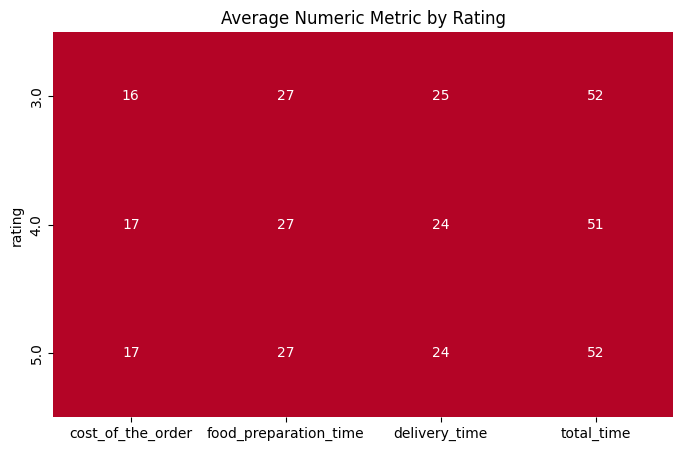

In [194]:
data_frame['total_time']=data_frame['food_preparation_time']+data_frame['delivery_time']

cols=['cost_of_the_order','food_preparation_time','delivery_time','total_time']
mean_by_rating=data_frame.groupby('rating')[cols].mean()
plt.figure(figsize=(8,5))
sns.heatmap(mean_by_rating,annot=True,cbar=False,cmap='coolwarm')
plt.title("Average Numeric Metric by Rating")
plt.show()

Observations:

Rating is not significantly impacted by cost,preparation or delievery time. Quite possibly Rating is impacted by quality and taste of the food.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [187]:
# Write the code here
"""
we created two additional columns avg_rating which stores the mean rating for each resturant and order_count which stores the total number of orders for each resturant
After that we filter out the resturants which has got atleast 50 orders and average rating greater than 4.
"""
resturant_offer=data_frame.groupby('restaurant_name').agg(avg_rating=('rating','mean'),order_count=('order_id','count')).reset_index()
eligible_resturants=resturant_offer[(resturant_offer['avg_rating']>4) & (resturant_offer['order_count']>50)]
eligible_count=len(eligible_resturants)
print("The following  " +f"{eligible_count} resturants are eligible for the promotional offer")
eligible_resturants.sort_values('avg_rating',ascending=False)



The following  7 resturants are eligible for the promotional offer


,restaurant_name,avg_rating,order_count
153,The Meatball Shop,4.511905,132
20,Blue Ribbon Fried Chicken,4.328125,96
136,Shake Shack,4.278195,219
121,RedFarm Broadway,4.243902,59
21,Blue Ribbon Sushi,4.219178,119
122,RedFarm Hudson,4.176471,55
109,Parm,4.128205,68


#### Observations:

In total 7 resturants are eligible for this promotional offer , all these resturants have rating count of more than 50 and average rating of more than 4.The top 3 shown in the above list is The Meatball Shop , Blue Ribbon Fried Chicken and Shake Shack


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [188]:
"""
we will create a new column in the data frame where we will store the computed revenue.
we will use np. where to apply the changes to the new column on the basis of the condition
mentioned in the queuestion
"""

data_frame['revenue']=np.where(data_frame['cost_of_the_order']>20,data_frame['cost_of_the_order'] * 0.25,
                               np.where(data_frame ['cost_of_the_order']>5,data_frame['cost_of_the_order'] * 0.15,0)
                               )
print("The net revenue generated by the company across all orders is USD ",data_frame['revenue'].sum())

print("="*50)
print("SAMPLE RECORDS")
print(data_frame[data_frame['cost_of_the_order']>=20][['order_id','cost_of_the_order','revenue']].head(1))
print(data_frame[(data_frame['cost_of_the_order']>=5) & (data_frame['cost_of_the_order']<20)][['order_id','cost_of_the_order','revenue']].
      head(1))
print(data_frame[data_frame['cost_of_the_order']<=5][['order_id','cost_of_the_order','revenue']].head(1))

The net revenue generated by the company across all orders is USD  6166.303
SAMPLE RECORDS
   order_id  cost_of_the_order  revenue
0   1477147              30.75   7.6875
   order_id  cost_of_the_order  revenue
1   1477685              12.08    1.812
    order_id  cost_of_the_order  revenue
82   1477790               4.75      0.0


#### Observations:

The total revenue generated by the company FoodHub is 6166.303 USD . The above sample records shows that the revenue has been calculated as per conditions laid down in the question .

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

Total orders:1898
Long orders: 200
The percentage of orders which takes more than 60 minutes is 10.537407797681771
Average value for prepation time and deleivery time
food_preparation_time    33.16
delivery_time            29.90
dtype: float64


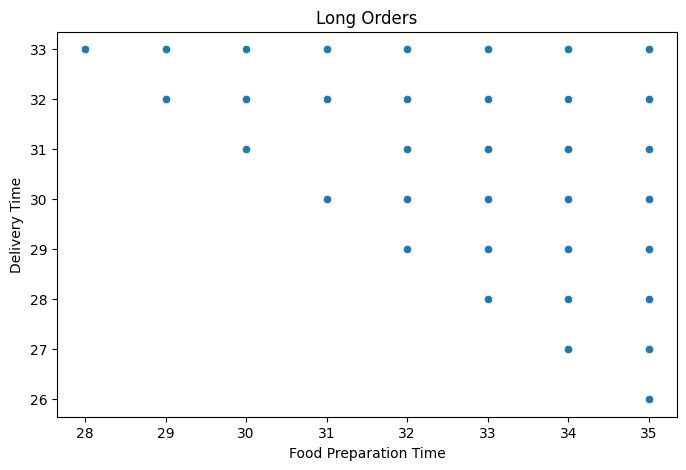

In [196]:
"""
we have already a new column total_time which is the combination of food
preparation time and delivery time, which help us calculate percentage of
orders which take more than 60 minutes to get delivered
"""
long_orders=len(data_frame[data_frame['total_time']>60])
total_orders=len(data_frame)
percentage=(long_orders/total_orders)*100
print(f"Total orders:{total_orders}")
print(f"Long orders: {long_orders}")
print(f"The percentage of orders which takes more than 60 minutes is {percentage}")

long_order_df=data_frame[data_frame['total_time']>60]
print("Average value for prepation time and deleivery time")
print(long_order_df[['food_preparation_time','delivery_time']].mean())

plt.figure(figsize=(8,5))
sns.scatterplot(data=long_order_df,x='food_preparation_time',y='delivery_time')
plt.title("Long Orders")
plt.xlabel("Food Preparation Time")
plt.ylabel("Delivery Time")
plt.show()



#### Observations:
1. As we can see only 10.53 % of orders taken total time of more than 60 minutes, which reflects a stable and consistent service from foodhub.But there can be a scope of improvement here.

2. we can see that for long orders both delivery time and food preparation time is higher , impying high traffic , some food items takes longer time to prepare.

3. Both preparation time and delivery time almost equally to longer total order time.But we can observe that perparation time is contibuting slightly higher to total time for order completion





### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

The mean delivery time for weekdays is 28.340036563071298
The mean delivery time for weekends is 22.4700222057735


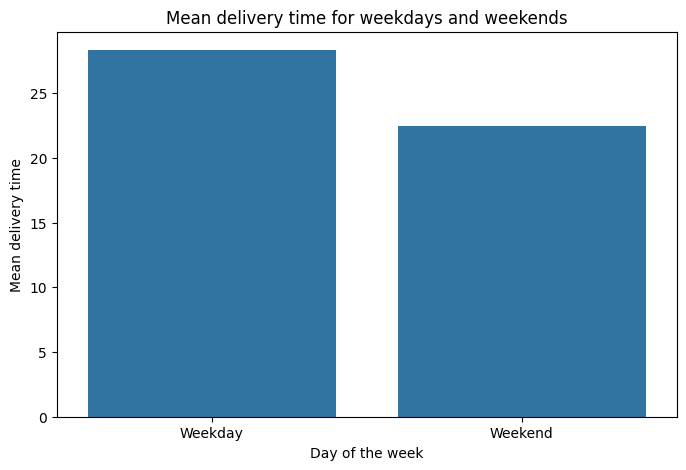

In [195]:
# Write the code here
mean_delivery_time=data_frame.groupby('day_of_the_week')['delivery_time'].mean()
print("The mean delivery time for weekdays is",mean_delivery_time['Weekday'])
print("The mean delivery time for weekends is",mean_delivery_time['Weekend'])
plt.figure(figsize=(8,5))
sns.barplot(x=mean_delivery_time.index,y=mean_delivery_time.values)
plt.title("Mean delivery time for weekdays and weekends")
plt.xlabel("Day of the week")
plt.ylabel("Mean delivery time")
plt.show()

#### Observations:
1. The mean delivery time during weekday is 28 minutes and during weekend is 22
   minutes, Inspite of number of orders in weekend being 2.5 times of number of combined orders in weekdays.

2. The lower delivery time during weekends indicates that there might be less traffic compared to weekdays and possibly more delivery personal are being added to cater to higher volume (2.5 times of weekdays)

3. Higher Delivery time in weekdays indicates there could be traffic congesation and other traffic restriction which are impacting delivery time



### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
1. American,Japnese, Italian and Chinese cuisines dominate the order volumes,refelecting customer preference . Vietnamese,Spanish,Southern,korean, even Thai cuisines are not prefered by customer as indicated by order volume

2. Customer rating are consistently high across most cuisines, showing strong overall satisfaction. However Vietnamese ,Mediterranean have very low ratings and wider spread indicating indicating inconsistent food quality across resturants offering these cuisines.

3. Food preparation time and Delivery times are highly consistent across cuisines (prep time 25-30 mins ,delivery time , 20-25 miins) indicating stable and consistent operational logistics/process, within cuisine type significantly not impacting prep and delivery time.

4. Resturants with very less orders may be artifically top rated , so filtering out resturants  with order count greater than 50 will give a reliable overview of the rating. we can see that The Meatball Soup, Blue Ribbon fried Chicken and Shake Shack are the top 3 highly rate resturants.

5. Delivery time during weekends is 22 minutes and in weekdays in 28 minutes, even though the order volume is 2.5 times higher during weekends.This indicates that company is able to handle higher volume of order, but in weekdays delivery time is impacted by other factors like traffic.

6. Total order time is more than 60 minutes for 10.53% or orders, with food preparation time contributing slightly more to the total time than delivery time

### Recommendations:

1. Since American,Japanese,Italian and Chinese restaurants are the most popular cuisines.Company should do the following
  
*    Increase the visibility of these cuisines through promotions and app based recommendations
*    Expand partnerships with similar high-demand restaurants to strengthen the demand  

2. Improve Quality for Underperforming Cuisines.Cuisines like Mediterranean and Vietnamese show inconsistent quality
  
*   Share quality improvement feedback based on rating insights.
*   Conduct targeted outreach to these restaurants.
*   Special offers on these cuisines

3. Cuisines like Indian, Mexican, Korean and Thai are highly rated but order volume is low.


*   Lauch add campaign in partnership with resturants to promote the cuisines
*   offer training or reciepe standardization as per local market demand.

4. Introduce Minimum Order Threshold for Rating-Based Badges


*   Only Top rated badges  based on order threshold value
*   Prevents misleading customer and ensures fair competition

5. Reduce High preparation time

*   Identify resturants having high preparation time and streamline the kitchen process.
*   Offer incentives for reducing preparation time

6. Customer Segmentation for Weekend Marketing

*   weekend order shows low spending customers we should introduce special combo offers
*   Push notifications for Weekdend offers

*   Promote cuisines with low cost offering.







